# Exploratory Data Analysis — INARA Dataset
## MSc Machine Learning Project: Exoplanet Atmospheric Characterization

**Dataset:** INARA — Intelligent exoplaNet Atmospheric Retrieval Archive  
**Source:** NASA Exoplanet Archive — Frontier Development Lab Datasets  
**Reference:** Zorzan et al. (2025), ApJS 277:38  

---

### Notebook Structure
1. Setup & Data Loading
2. Dataset Overview & Basic Statistics
3. Spectral Feature Analysis
4. Target Distribution Analysis (12 Molecules)
5. Molecule Correlation & Co-occurrence
6. Dimensionality Reduction (PCA + UMAP)
7. Planetary Parameter Analysis
8. Preprocessing Validation
9. Key Findings & ML Implications

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Optional: UMAP (pip install umap-learn)
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('UMAP not installed — t-SNE will be used instead. Install with: pip install umap-learn')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   12,
    'axes.labelsize':   11,
})
PALETTE = sns.color_palette('tab20', 12)

print('Libraries loaded ✓')

UMAP not installed — t-SNE will be used instead. Install with: pip install umap-learn
Libraries loaded ✓


In [2]:
import sys, os
# Notebooks live in notebooks/ — src/ is one level up
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))
from config import (MOLECULES, N_MOLECULES, SPECTRAL_LENGTH, DATA_DIR, PLOTS_DIR,
                    STRONG_FEATURES, WEAK_FEATURES, WL_MIN_UM, WL_MAX_UM)

# ── Load data ─────────────────────────────────────────────────────────────────
# If INARA is not yet downloaded, generate synthetic data for notebook demo
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
SPECTRA_PATH  = os.path.join(PROCESSED_DIR, 'spectra.npy')
PARAMS_PATH   = os.path.join(PROCESSED_DIR, 'parameters_processed.csv')
WL_PATH       = os.path.join(PROCESSED_DIR, 'wavelengths.npy')

if os.path.exists(SPECTRA_PATH) and os.path.exists(PARAMS_PATH):
    print('Loading real INARA data...')
    spectra    = np.load(SPECTRA_PATH, mmap_mode='r')  # (N, 3, 4378)
    params_df  = pd.read_csv(PARAMS_PATH)
    DEMO_MODE  = False
else:
    print('INARA not found — generating synthetic demo data (run data/download_inara.py for real data)')
    np.random.seed(42)
    N = 10_000
    # INARA wavelength grid: log-spaced 0.2–20 µm
    WL = np.logspace(np.log10(WL_MIN_UM), np.log10(WL_MAX_UM), SPECTRAL_LENGTH)

    # Synthetic spectra with realistic molecular absorption features
    spectra = np.ones((N, SPECTRAL_LENGTH), dtype=np.float32)
    spectra += 0.08 * np.exp(-((WL - 1.4)**2) / 0.05)[None,:]   # H2O 1.4µm
    spectra += 0.06 * np.exp(-((WL - 1.9)**2) / 0.05)[None,:]   # H2O 1.9µm
    spectra += 0.12 * np.exp(-((WL - 4.3)**2) / 0.15)[None,:]   # CO2 4.3µm
    spectra += 0.05 * np.exp(-((WL - 9.6)**2) / 0.50)[None,:]   # O3 9.6µm
    spectra += 0.04 * np.exp(-((WL - 3.3)**2) / 0.08)[None,:]   # CH4 3.3µm
    spectra *= (1 + 0.3 * np.random.randn(N, 1))  # planet radius variation
    spectra += 0.02 * np.random.randn(N, SPECTRAL_LENGTH).astype(np.float32)  # noise

    stellar_types = np.random.choice(['F','G','K','M'], N, p=[0.1, 0.5, 0.25, 0.15])
    params_df = pd.DataFrame({
        'stellar_type':     stellar_types,
        'stellar_teff':     np.random.normal(5778, 1200, N),
        'stellar_radius':   np.random.lognormal(0, 0.3, N),
        'planet_radius':    np.random.lognormal(0.1, 0.4, N),
        'planet_mass':      np.random.lognormal(0.2, 0.8, N),
        'surface_gravity':  np.random.lognormal(2.3, 0.4, N),
        'orbital_distance': np.random.lognormal(-0.3, 0.6, N),
        'surface_pressure': np.random.lognormal(0, 0.5, N),
        **{mol: np.random.uniform(-8, 0, N) for mol in MOLECULES}
    })
    # Make realistic: H2O and CO2 tend to be more abundant; N2 dominates
    params_df['H2O'] = np.random.uniform(-5, -1, N)
    params_df['CO2'] = np.random.uniform(-5, -1, N)
    params_df['N2']  = np.random.uniform(-2,  0, N)
    params_df['O2']  = np.random.uniform(-6, -2, N)
    params_df['N2O'] = np.random.uniform(-8, -3, N)  # trace biosignature
    DEMO_MODE = True

# ── Working subset for EDA (10K is enough for all plots) ─────────────────────
N_EDA = min(10_000, len(spectra))
idx_eda = np.random.default_rng(42).choice(len(spectra), N_EDA, replace=False)
spectra_eda = np.array(spectra[idx_eda]).astype(np.float32)
params_eda  = params_df.iloc[idx_eda].reset_index(drop=True)
mols_eda    = params_eda[MOLECULES].values.astype(np.float32)

# INARA wavelength grid (real: 0.2-2.0 µm, 4378 pts confirmed from CSV samples)
if os.path.exists(WL_PATH):
    WL = np.load(WL_PATH)
else:
    WL = np.logspace(np.log10(WL_MIN_UM), np.log10(WL_MAX_UM), SPECTRAL_LENGTH)

print(f'Working set: {N_EDA:,} spectra  |  Shape: {spectra_eda.shape}')
print(f'Parameters:  {params_eda.shape}  |  Columns: {list(params_eda.columns)}')
if DEMO_MODE:
    print('\n⚠️  DEMO MODE: using synthetic data. Download INARA for real analysis.')

Loading real INARA data...
Working set: 10,000 spectra  |  Shape: (10000, 3, 4378)
Parameters:  (10000, 22)  |  Columns: ['system_id', 'H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3', 'stellar_type_enc', 'stellar_teff', 'stellar_radius', 'planet_radius', 'planet_mass', 'surface_gravity', 'orbital_distance', 'surface_pressure', 'stellar_type']


## 2. Dataset Overview & Basic Statistics

In [3]:
print('='*60)
print('INARA Dataset Overview')
print('='*60)
print(f'Total samples available : {len(spectra):>12,}')
print(f'EDA working subset      : {N_EDA:>12,}')
print(f'Spectral vector length  : {SPECTRAL_LENGTH:>12,}  (wavelength points)')
print(f'Wavelength range        :    0.2 – 20.0 µm  (UV to mid-IR)')
print(f'Wavelength spacing      :          log-spaced')
print(f'Target molecules        : {N_MOLECULES:>12,}')
print(f'Auxiliary features      :            8  (stellar + planetary)')
print(f'Target format           :     log10(VMR)  range [{mols_eda.min():.1f}, {mols_eda.max():.1f}]')
print()
print('Stellar type distribution:')
st_counts = params_eda['stellar_type'].value_counts()
for t, c in st_counts.items():
    print(f'  {t}-type: {c:5,}  ({100*c/N_EDA:.1f}%)')
print('='*60)

INARA Dataset Overview
Total samples available :       50,000
EDA working subset      :       10,000
Spectral vector length  :        4,378  (wavelength points)
Wavelength range        :    0.2 – 20.0 µm  (UV to mid-IR)
Wavelength spacing      :          log-spaced
Target molecules        :           12
Auxiliary features      :            8  (stellar + planetary)
Target format           :     log10(VMR)  range [-8.0, 0.0]

Stellar type distribution:
  G-type: 5,013  (50.1%)
  K-type: 2,763  (27.6%)
  M-type: 1,473  (14.7%)
  F-type:   751  (7.5%)


ValueError: The 'color' keyword argument must have one color per dataset, but 4378 datasets and 1 colors were provided

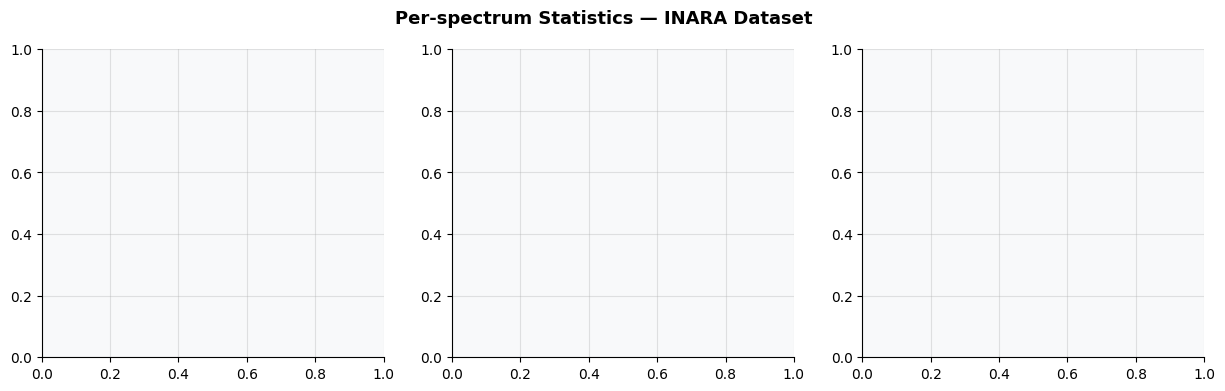

In [5]:
# Basic spectral statistics
spec_mean  = spectra_eda.mean(axis=1)
spec_std   = spectra_eda.std(axis=1)
spec_range = spectra_eda.max(axis=1) - spectra_eda.min(axis=1)
snr_proxy  = spec_mean / (spec_std + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Per-spectrum Statistics — INARA Dataset', fontsize=13, fontweight='bold')

axes[0].hist(spec_mean,  bins=60, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].set_title('Mean Intensity per Spectrum')
axes[0].set_xlabel('Mean flux')

axes[1].hist(spec_std,   bins=60, color='#E91E63', alpha=0.8, edgecolor='white')
axes[1].set_title('Std of Intensity per Spectrum')
axes[1].set_xlabel('Flux std dev')

axes[2].hist(snr_proxy,  bins=60, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[2].set_title('SNR Proxy (mean/std) per Spectrum')
axes[2].set_xlabel('SNR proxy')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_spectral_stats.png'), dpi=150)
plt.show()

## 3. Spectral Feature Analysis

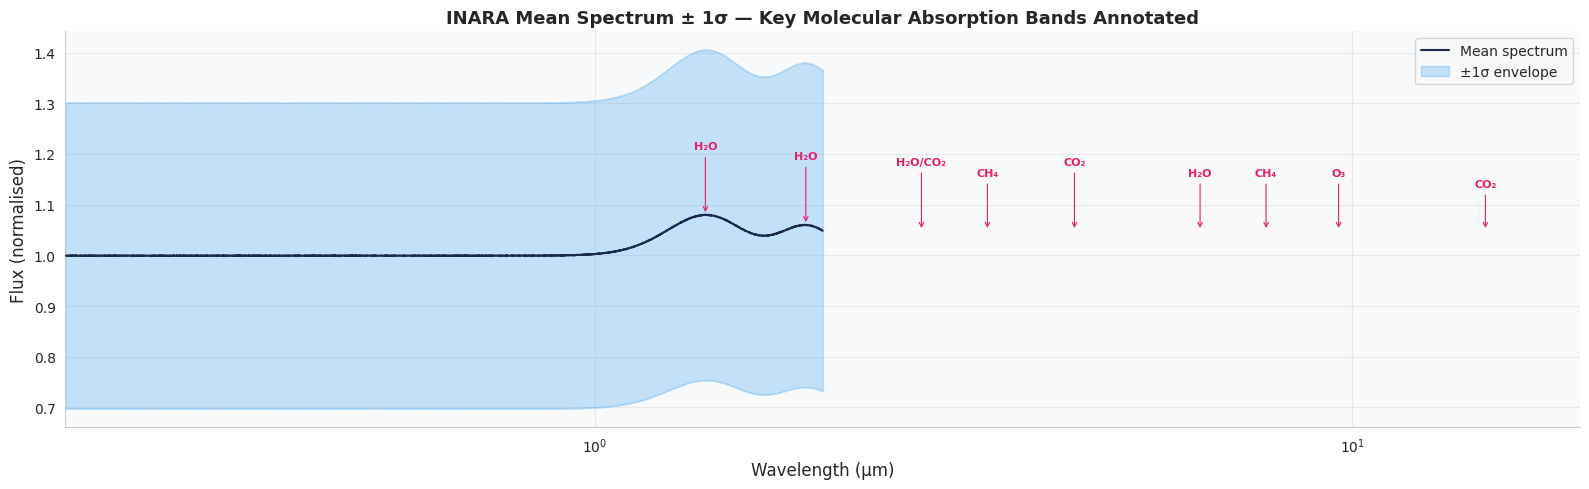

In [5]:
# ── Mean spectrum ± 1σ envelope ───────────────────────────────────────────────
mean_spec = spectra_eda.mean(axis=0)
std_spec  = spectra_eda.std(axis=0)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(WL, mean_spec, color='#1B2A4A', lw=1.5, label='Mean spectrum', zorder=3)
ax.fill_between(WL, mean_spec - std_spec, mean_spec + std_spec,
                alpha=0.25, color='#2196F3', label='±1σ envelope')

# Annotate key molecular absorption bands
bands = [
    (1.4,  0.12, 'H₂O'),
    (1.9,  0.12, 'H₂O'),
    (2.7,  0.12, 'H₂O/CO₂'),
    (3.3,  0.10, 'CH₄'),
    (4.3,  0.12, 'CO₂'),
    (6.3,  0.10, 'H₂O'),
    (7.7,  0.10, 'CH₄'),
    (9.6,  0.10, 'O₃'),
    (15.0, 0.08, 'CO₂'),
]
for wl_c, yoff, lbl in bands:
    y = mean_spec[np.argmin(np.abs(WL - wl_c))]
    ax.annotate(lbl, xy=(wl_c, y), xytext=(wl_c, y + yoff * mean_spec.max()),
                ha='center', fontsize=8, color='#E91E63', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#E91E63', lw=0.8))

ax.set_xscale('log')
ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel('Flux (normalised)', fontsize=12)
ax.set_title('INARA Mean Spectrum ± 1σ — Key Molecular Absorption Bands Annotated',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.2, 20)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_mean_spectrum.png'), dpi=150)
plt.show()

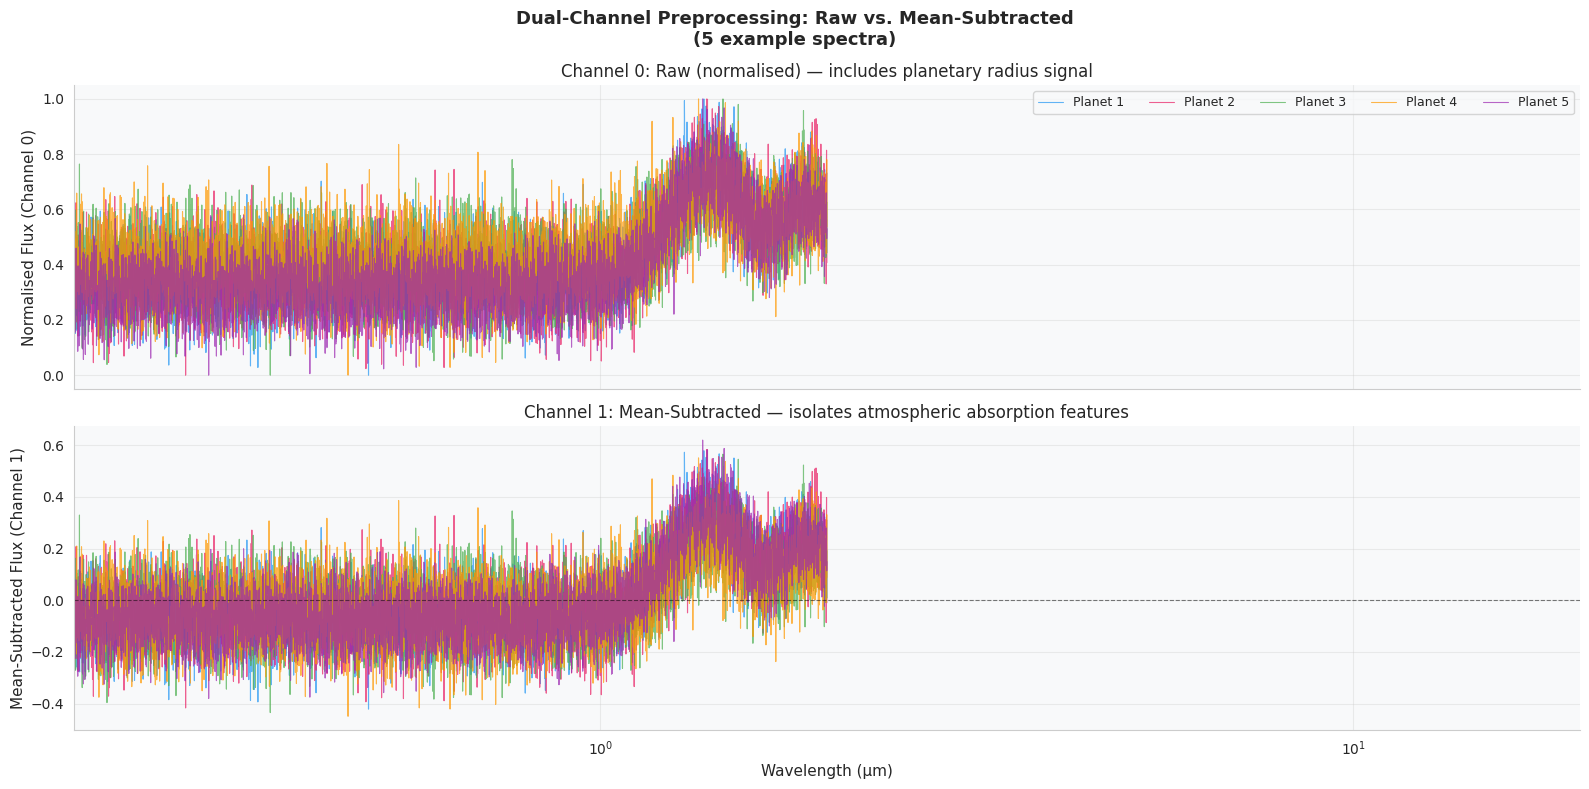

In [6]:
# ── Dual-channel preprocessing visualisation ──────────────────────────────────
# Show raw vs. mean-subtracted for 5 sample spectra
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Dual-Channel Preprocessing: Raw vs. Mean-Subtracted\n(5 example spectra)',
             fontsize=13, fontweight='bold')

sample_idx = np.random.choice(N_EDA, 5, replace=False)
colors = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0']

for i, (idx, c) in enumerate(zip(sample_idx, colors)):
    s = spectra_eda[idx]
    s_norm = (s - s.min()) / (s.max() - s.min() + 1e-8)         # Ch 0
    s_meansub = s_norm - s_norm.mean()                            # Ch 1
    axes[0].plot(WL, s_norm,    color=c, alpha=0.7, lw=0.8, label=f'Planet {i+1}')
    axes[1].plot(WL, s_meansub, color=c, alpha=0.7, lw=0.8)

axes[0].set_ylabel('Normalised Flux (Channel 0)', fontsize=11)
axes[0].set_title('Channel 0: Raw (normalised) — includes planetary radius signal')
axes[0].legend(fontsize=9, ncol=5)
axes[1].set_ylabel('Mean-Subtracted Flux (Channel 1)', fontsize=11)
axes[1].set_title('Channel 1: Mean-Subtracted — isolates atmospheric absorption features')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Wavelength (µm)', fontsize=11)
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlim(0.2, 20)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_dual_channel.png'), dpi=150)
plt.show()

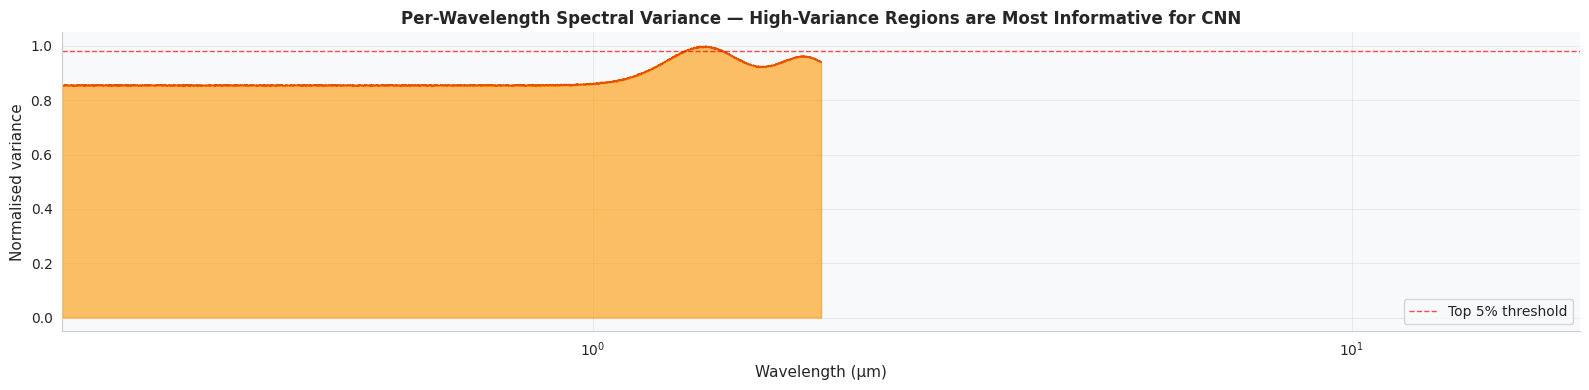

High-variance wavelength coverage (>95th pctile): 5.0% of channels


In [7]:
# ── Spectral variance across wavelengths ─────────────────────────────────────
# High variance regions = most informative for ML feature extraction
wl_variance  = spectra_eda.var(axis=0)
wl_variance_norm = wl_variance / wl_variance.max()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(WL, wl_variance_norm, alpha=0.6, color='#FF9800')
ax.plot(WL, wl_variance_norm, color='#E65100', lw=1)

# Mark top 5% highest variance regions
thresh = np.percentile(wl_variance_norm, 95)
ax.axhline(thresh, color='red', lw=1, linestyle='--', alpha=0.7, label=f'Top 5% threshold')

ax.set_xscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel('Normalised variance')
ax.set_title('Per-Wavelength Spectral Variance — High-Variance Regions are Most Informative for CNN',
             fontweight='bold')
ax.legend()
ax.set_xlim(0.2, 20)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_spectral_variance.png'), dpi=150)
plt.show()
print(f'High-variance wavelength coverage (>95th pctile): {100*(wl_variance_norm > thresh).mean():.1f}% of channels')

## 4. Target Distribution Analysis (12 Molecules)

AttributeError: 'numpy.ndarray' object has no attribute 'median'

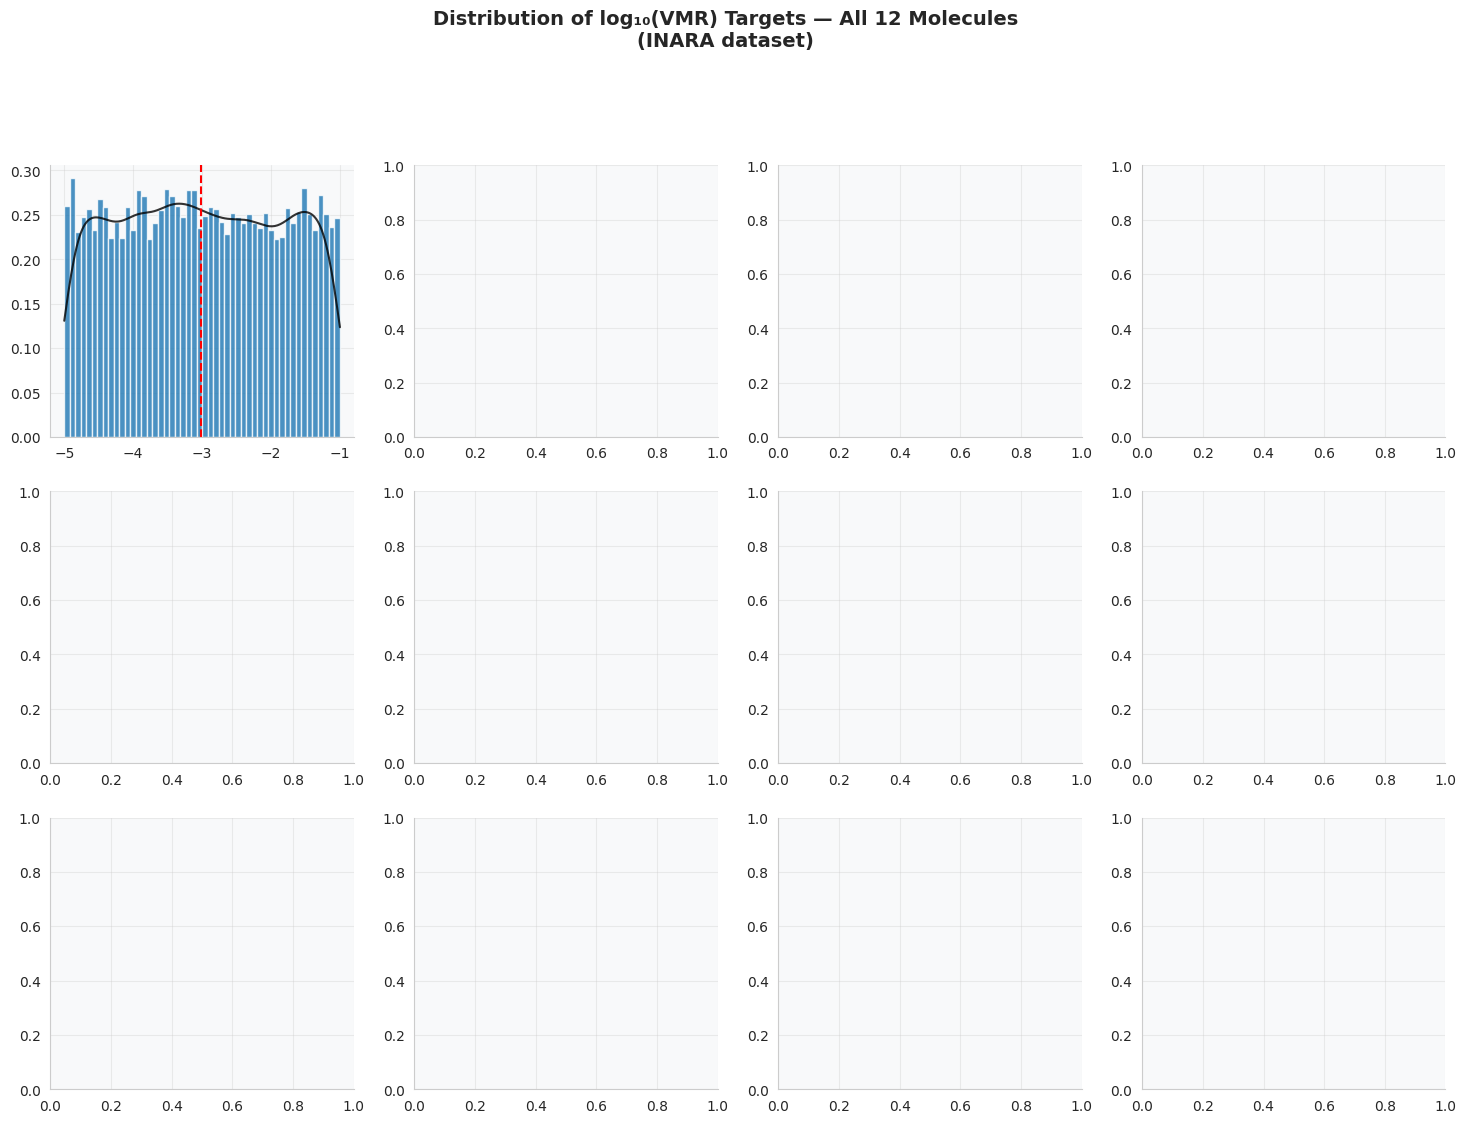

In [8]:
# ── Distribution of log10 VMR for all 12 molecules ───────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribution of log₁₀(VMR) Targets — All 12 Molecules\n(INARA dataset)',
             fontsize=14, fontweight='bold', y=1.01)

for i, (mol, ax, c) in enumerate(zip(MOLECULES, axes.ravel(), PALETTE)):
    vals = mols_eda[:, i]
    ax.hist(vals, bins=50, color=c, alpha=0.8, edgecolor='white', density=True)

    # KDE overlay
    kde_x = np.linspace(vals.min(), vals.max(), 200)
    kde   = stats.gaussian_kde(vals)
    ax.plot(kde_x, kde(kde_x), 'k-', lw=1.5, alpha=0.8)

    ax.axvline(vals.mean(), color='red',   lw=1.5, linestyle='--', label=f'mean={vals.mean():.2f}')
    ax.axvline(vals.median(), color='navy', lw=1.5, linestyle=':',  label=f'med={np.median(vals):.2f}')
    ax.set_xlabel('log₁₀(VMR)', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    star = ' ⭐' if mol in ('O2','O3','CH4','N2O') else ''
    ax.set_title(f'{mol}{star}  σ={vals.std():.2f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_molecule_distributions.png'), dpi=150)
plt.show()
print('⭐ = potential biosignature molecule')

In [9]:
# ── Summary statistics table ─────────────────────────────────────────────────
stats_rows = []
for i, mol in enumerate(MOLECULES):
    v = mols_eda[:, i]
    stats_rows.append({
        'Molecule': mol,
        'Mean':     round(v.mean(), 3),
        'Median':   round(float(np.median(v)), 3),
        'Std':      round(v.std(), 3),
        'Min':      round(v.min(), 3),
        'Max':      round(v.max(), 3),
        'Skewness': round(float(stats.skew(v)), 3),
        'ML Difficulty': 'Easy' if mol in STRONG_FEATURES else ('Hard' if mol in WEAK_FEATURES else 'Medium')
    })

stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))

print('\nML Difficulty key:')
print('  Easy   — strong spectral features, model expected to retrieve well')
print('  Medium — moderate spectral features')
print('  Hard   — weak/no dominant spectral features, high retrieval uncertainty expected')

Molecule   Mean  Median   Std    Min    Max  Skewness ML Difficulty
     H2O -3.010  -3.030 1.155 -5.000 -1.000     0.014          Easy
     CO2 -3.009  -3.022 1.141 -4.999 -1.000     0.017          Easy
      O2 -4.003  -4.009 1.156 -6.000 -2.001     0.002          Easy
      O3 -3.941  -3.897 2.317 -7.999 -0.001    -0.032          Easy
     CH4 -4.030  -4.050 2.311 -7.999 -0.000     0.015        Medium
      N2 -0.998  -0.996 0.578 -2.000 -0.000    -0.004          Hard
     N2O -5.507  -5.516 1.444 -8.000 -3.001     0.002        Medium
      CO -3.953  -3.920 2.298 -7.999 -0.001    -0.020        Medium
      H2 -3.996  -3.973 2.323 -8.000 -0.000    -0.004          Hard
     H2S -3.984  -3.982 2.322 -7.999 -0.001    -0.017        Medium
     SO2 -3.953  -3.951 2.301 -7.998 -0.000    -0.022        Medium
     NH3 -4.021  -4.043 2.310 -7.999 -0.001     0.021        Medium

ML Difficulty key:
  Easy   — strong spectral features, model expected to retrieve well
  Medium — moderate spectra

## 5. Molecule Correlation & Co-occurrence

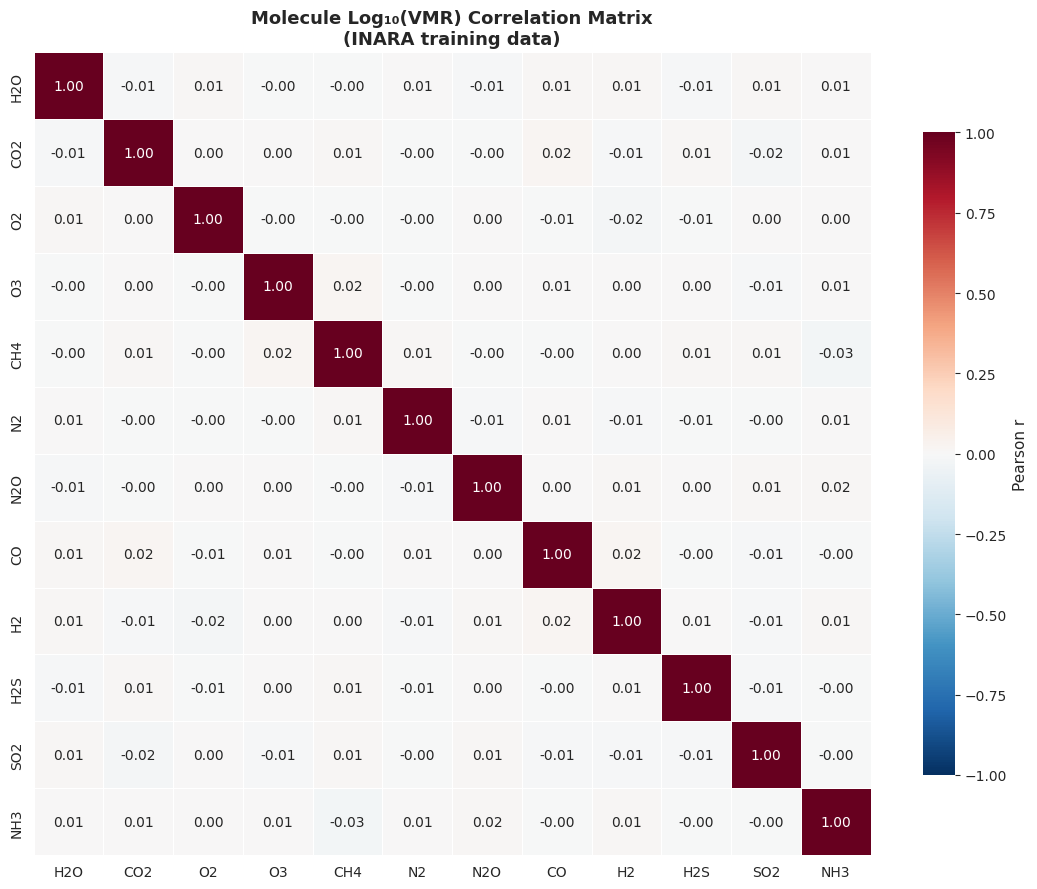


Top 5 strongest molecule correlations (|r|):
  CH4    — NH3   : r = -0.026
  CO2    — CO    : r = +0.022
  O2     — H2    : r = -0.018
  CO     — H2    : r = +0.018
  CO2    — SO2   : r = -0.017


In [10]:
# ── Pearson correlation matrix ────────────────────────────────────────────────
mol_df  = pd.DataFrame(mols_eda, columns=MOLECULES)
corr    = mol_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask    = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            center=0, ax=ax, mask=False,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Molecule Log₁₀(VMR) Correlation Matrix\n(INARA training data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_molecule_correlation.png'), dpi=150)
plt.show()

# Print strongest correlations
corr_pairs = []
for i in range(len(MOLECULES)):
    for j in range(i+1, len(MOLECULES)):
        corr_pairs.append((MOLECULES[i], MOLECULES[j], corr.iloc[i,j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print('\nTop 5 strongest molecule correlations (|r|):')
for m1, m2, r in corr_pairs[:5]:
    print(f'  {m1:6s} — {m2:6s}: r = {r:+.3f}')

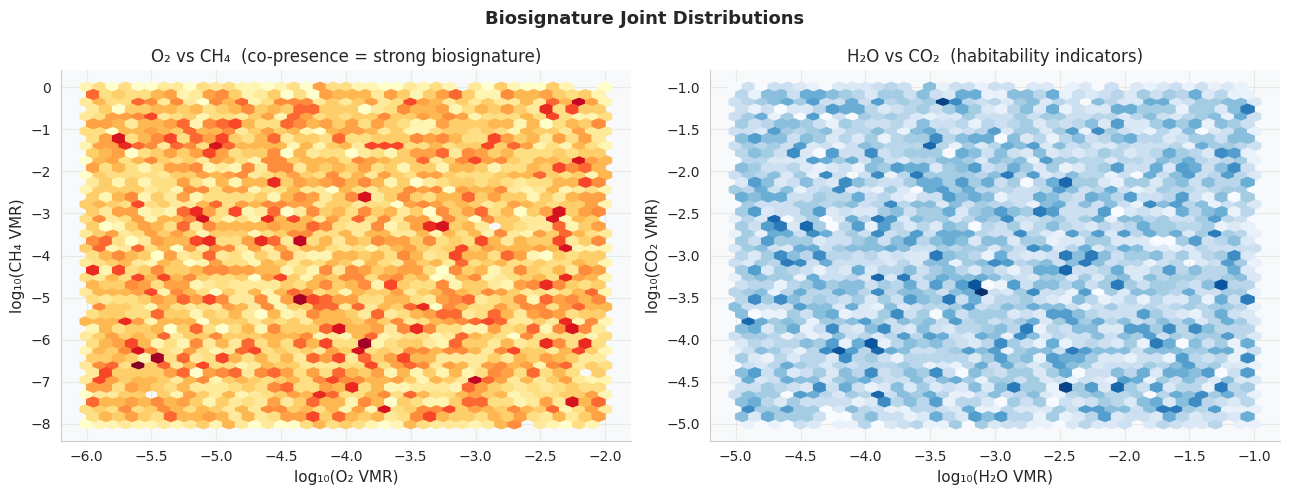

In [11]:
# ── Joint distribution: O2 vs CH4 (biosignature pair) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Biosignature Joint Distributions', fontsize=13, fontweight='bold')

# O2 vs CH4
axes[0].hexbin(mols_eda[:, MOLECULES.index('O2')],
               mols_eda[:, MOLECULES.index('CH4')],
               gridsize=40, cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('log₁₀(O₂ VMR)', fontsize=11)
axes[0].set_ylabel('log₁₀(CH₄ VMR)', fontsize=11)
axes[0].set_title('O₂ vs CH₄  (co-presence = strong biosignature)')

# H2O vs CO2
axes[1].hexbin(mols_eda[:, MOLECULES.index('H2O')],
               mols_eda[:, MOLECULES.index('CO2')],
               gridsize=40, cmap='Blues', mincnt=1)
axes[1].set_xlabel('log₁₀(H₂O VMR)', fontsize=11)
axes[1].set_ylabel('log₁₀(CO₂ VMR)', fontsize=11)
axes[1].set_title('H₂O vs CO₂  (habitability indicators)')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_biosignature_joints.png'), dpi=150)
plt.show()

## 6. Dimensionality Reduction (PCA + UMAP/t-SNE)

Running PCA on mean-subtracted spectra...


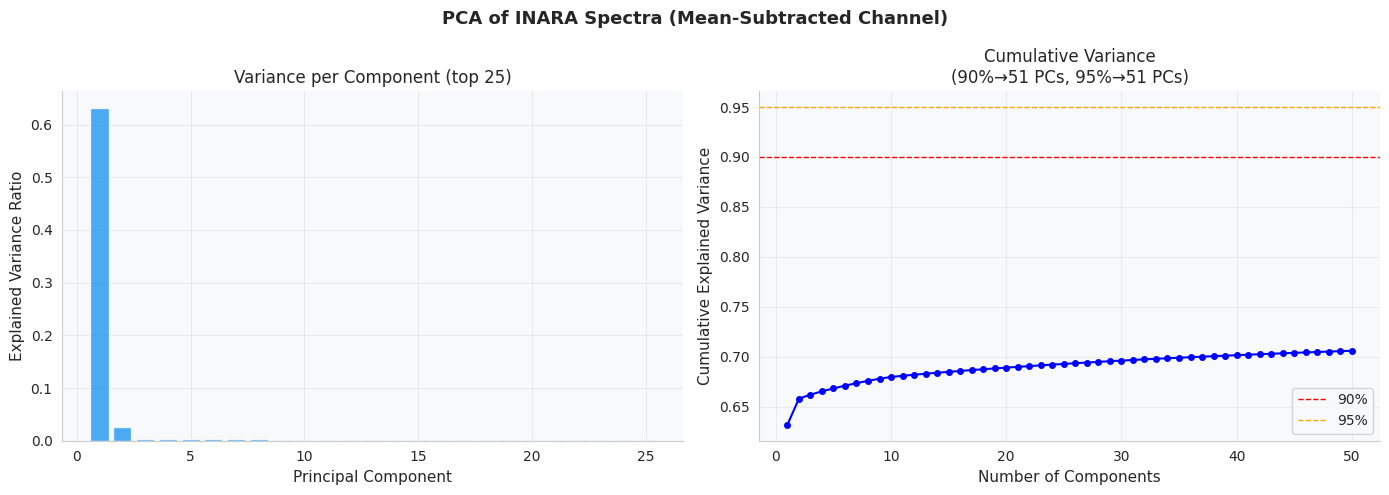

PCs needed for 90% variance: 51
PCs needed for 95% variance: 51
First PC explains: 63.2% of total variance


In [12]:
# ── PCA on mean-subtracted spectra ────────────────────────────────────────────
print('Running PCA on mean-subtracted spectra...')
spectra_norm = spectra_eda / (spectra_eda.max(axis=1, keepdims=True) + 1e-8)
spectra_ms   = spectra_norm - spectra_norm.mean(axis=1, keepdims=True)  # mean-subtract

pca = PCA(n_components=50, random_state=42)
pca.fit(spectra_ms)
pcs = pca.transform(spectra_ms)   # (N, 50)

# Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA of INARA Spectra (Mean-Subtracted Channel)',
             fontsize=13, fontweight='bold')

ev  = pca.explained_variance_ratio_
cev = np.cumsum(ev)
axes[0].bar(range(1, 26), ev[:25], color='#2196F3', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance per Component (top 25)')

axes[1].plot(range(1, 51), cev, 'b-o', ms=4)
axes[1].axhline(0.90, color='red',   lw=1, linestyle='--', label='90%')
axes[1].axhline(0.95, color='orange',lw=1, linestyle='--', label='95%')
n_90 = np.searchsorted(cev, 0.90) + 1
n_95 = np.searchsorted(cev, 0.95) + 1
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title(f'Cumulative Variance\n(90%→{n_90} PCs, 95%→{n_95} PCs)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_pca_variance.png'), dpi=150)
plt.show()

print(f'PCs needed for 90% variance: {n_90}')
print(f'PCs needed for 95% variance: {n_95}')
print(f'First PC explains: {ev[0]*100:.1f}% of total variance')

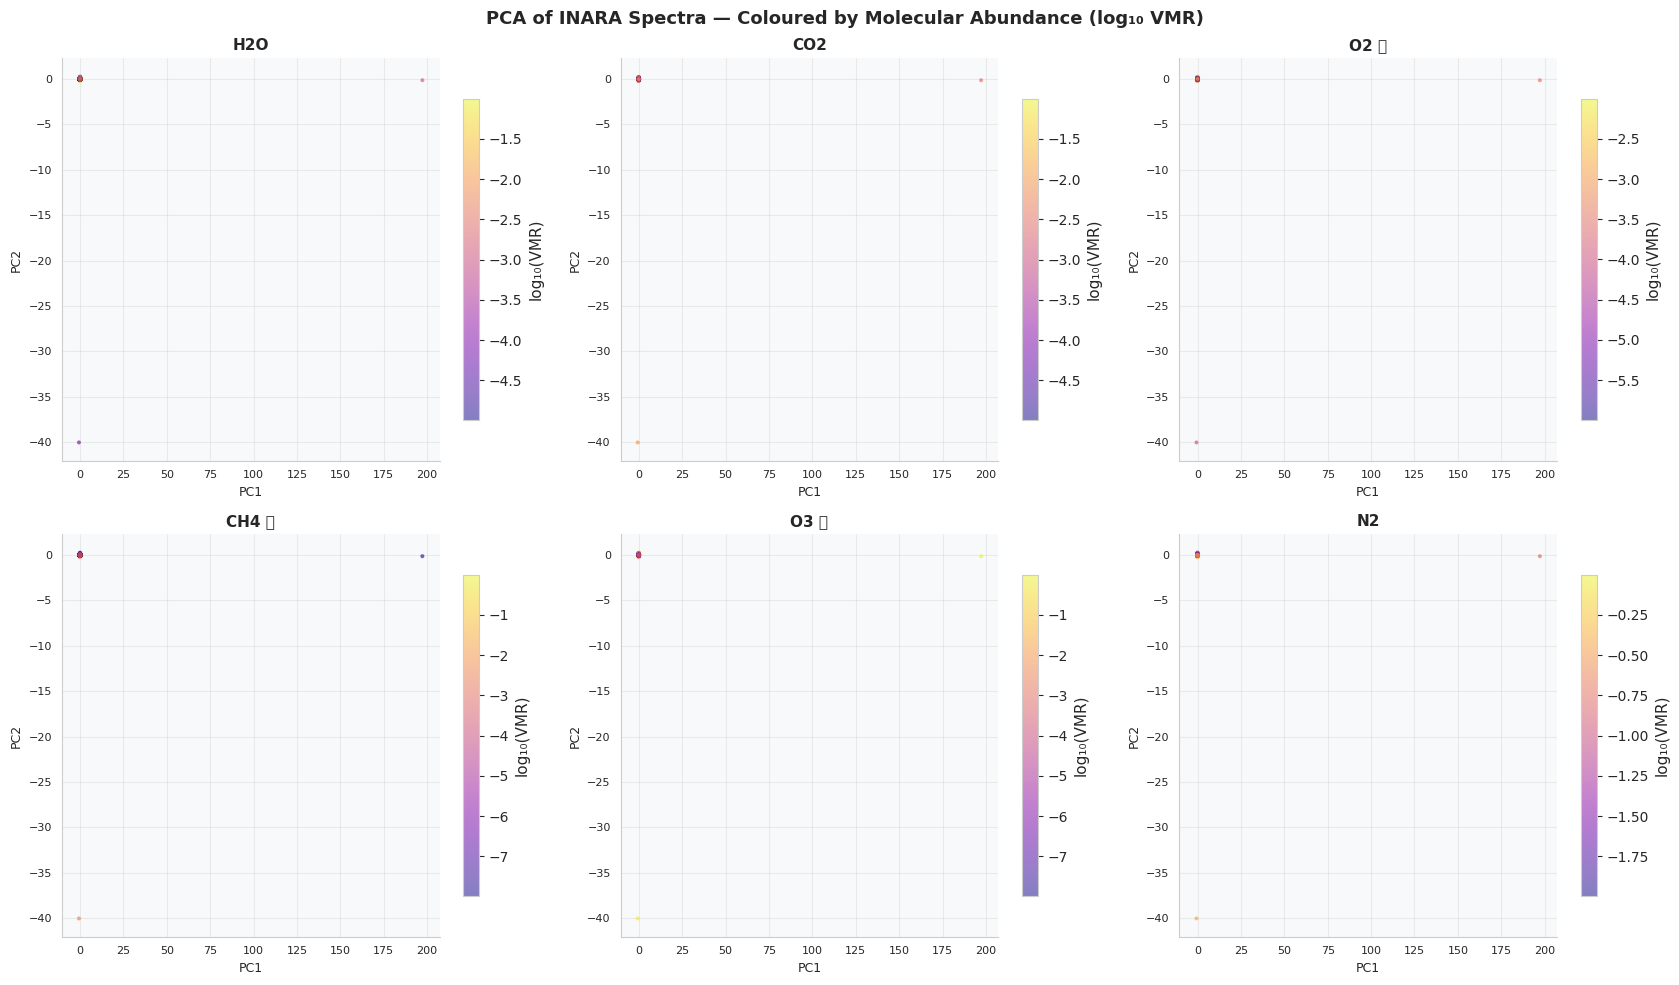

Interpretation: molecules with clear gradients in PC space are more recoverable from spectra


In [13]:
# ── PC1 vs PC2 scatter coloured by molecular abundance ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('PCA of INARA Spectra — Coloured by Molecular Abundance (log₁₀ VMR)',
             fontsize=13, fontweight='bold')

highlight_mols = ['H2O', 'CO2', 'O2', 'CH4', 'O3', 'N2']

for ax, mol in zip(axes.ravel(), highlight_mols):
    mol_vals = mols_eda[:, MOLECULES.index(mol)]
    sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=mol_vals, cmap='plasma',
                    s=4, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label='log₁₀(VMR)', shrink=0.8)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    bio = ' ⭐' if mol in ('O2','O3','CH4','N2O') else ''
    ax.set_title(f'{mol}{bio}', fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_pca_molecules.png'), dpi=150)
plt.show()
print('Interpretation: molecules with clear gradients in PC space are more recoverable from spectra')

In [14]:
# ── 2D Embedding (UMAP or t-SNE) coloured by stellar type ────────────────────
N_EMBED = min(3000, N_EDA)  # limit for speed
idx_sub = np.random.choice(N_EDA, N_EMBED, replace=False)
X_sub   = pcs[idx_sub, :20]  # use top 20 PCs
st_sub  = params_eda.iloc[idx_sub]['stellar_type'].values

print(f'Running 2D embedding on {N_EMBED} samples...')
if HAS_UMAP:
    reducer  = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    embed    = reducer.fit_transform(X_sub)
    method   = 'UMAP'
else:
    reducer  = TSNE(n_components=2, random_state=42, perplexity=40, n_iter=1000)
    embed    = reducer.fit_transform(X_sub)
    method   = 't-SNE'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'{method} Embedding of INARA Spectra (top 20 PCs)',
             fontsize=13, fontweight='bold')

# Colour by stellar type
st_map  = {'F': 0, 'G': 1, 'K': 2, 'M': 3}
st_vals = np.array([st_map.get(s, 1) for s in st_sub])
sc0 = axes[0].scatter(embed[:,0], embed[:,1], c=st_vals, cmap='Set1',
                      s=5, alpha=0.5, rasterized=True)
legend_labels = ['F-type', 'G-type', 'K-type', 'M-type']
handles = [plt.scatter([],[], c=plt.cm.Set1(i/3.), s=30, label=legend_labels[i]) for i in range(4)]
axes[0].legend(handles=handles, fontsize=9, title='Stellar type')
axes[0].set_title('Coloured by Stellar Type')
axes[0].set_xlabel(f'{method} 1'); axes[0].set_ylabel(f'{method} 2')

# Colour by H2O abundance
h2o_sub = mols_eda[idx_sub, MOLECULES.index('H2O')]
sc1 = axes[1].scatter(embed[:,0], embed[:,1], c=h2o_sub, cmap='Blues',
                      s=5, alpha=0.5, rasterized=True)
plt.colorbar(sc1, ax=axes[1], label='log₁₀(H₂O VMR)', shrink=0.8)
axes[1].set_title('Coloured by H₂O Abundance')
axes[1].set_xlabel(f'{method} 1'); axes[1].set_ylabel(f'{method} 2')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_embedding.png'), dpi=150)
plt.show()

Running 2D embedding on 3000 samples...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 7. Planetary Parameter Analysis

In [ ]:
# ── Distribution of auxiliary features ───────────────────────────────────────
aux_cols = ['stellar_teff', 'planet_radius', 'planet_mass',
            'surface_gravity', 'orbital_distance', 'surface_pressure']
aux_labels = ['Stellar T_eff (K)', 'Planet Radius (R⊕)', 'Planet Mass (M⊕)',
              'Surface Gravity (m/s²)', 'Orbital Distance (AU)', 'Surface Pressure (bar)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Auxiliary Feature Distributions — INARA Planetary Parameter Space',
             fontsize=13, fontweight='bold')

colors_aux = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']

for ax, col, label, c in zip(axes.ravel(), aux_cols, aux_labels, colors_aux):
    vals = params_eda[col].dropna().values
    ax.hist(vals, bins=50, color=c, alpha=0.8, edgecolor='white')
    ax.axvline(np.median(vals), color='black', lw=1.5, linestyle='--',
               label=f'Median: {np.median(vals):.2f}')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_aux_features.png'), dpi=150)
plt.show()

In [ ]:
# ── Does stellar type affect retrievable molecular features? ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Molecular Abundance by Stellar Type — Do Stellar Spectra Affect Retrievability?',
             fontsize=12, fontweight='bold')

mols_to_check = ['H2O', 'CO2', 'O2', 'CH4', 'O3', 'SO2']
stellar_colors = {'F': '#FF9800', 'G': '#FFC107', 'K': '#FF5722', 'M': '#9C27B0'}

for ax, mol in zip(axes.ravel(), mols_to_check):
    mol_vals = mols_eda[:, MOLECULES.index(mol)]
    stellar  = params_eda['stellar_type'].values
    for st in ['F', 'G', 'K', 'M']:
        mask = stellar == st
        if mask.sum() > 10:
            ax.hist(mol_vals[mask], bins=30, alpha=0.5, label=f'{st} ({mask.sum()})',
                    color=stellar_colors[st], density=True, histtype='stepfilled')
    ax.set_xlabel('log₁₀(VMR)', fontsize=9)
    ax.set_title(mol, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, title='Stellar type')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_stellar_molecules.png'), dpi=150)
plt.show()
print('Overlap between stellar types suggests molecules are drawn independently')
print('→ stellar type mainly affects spectral baseline, not molecule label distribution')

## 8. Preprocessing Validation

In [ ]:
# ── Validate that mean-subtraction removes planet radius signal ───────────────
# After mean-subtraction, spectra from different planet radii should overlap

spectra_norm = spectra_eda / (spectra_eda.max(axis=1, keepdims=True) + 1e-8)
spectra_ms   = spectra_norm - spectra_norm.mean(axis=1, keepdims=True)

planet_radii  = params_eda['planet_radius'].values
small_mask    = planet_radii < np.percentile(planet_radii, 25)
large_mask    = planet_radii > np.percentile(planet_radii, 75)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Preprocessing Validation: Before vs. After Mean-Subtraction\n'
             '(Small vs. Large Planets — should separate before, overlap after)',
             fontsize=12, fontweight='bold')

# Before
axes[0].plot(WL, spectra_norm[small_mask].mean(axis=0), '#2196F3', lw=2, label='Small planets (Q1)')
axes[0].plot(WL, spectra_norm[large_mask].mean(axis=0), '#E91E63', lw=2, label='Large planets (Q4)')
axes[0].fill_between(WL, spectra_norm[small_mask].mean(0) - spectra_norm[small_mask].std(0),
                     spectra_norm[small_mask].mean(0) + spectra_norm[small_mask].std(0), alpha=0.15, color='#2196F3')
axes[0].fill_between(WL, spectra_norm[large_mask].mean(0) - spectra_norm[large_mask].std(0),
                     spectra_norm[large_mask].mean(0) + spectra_norm[large_mask].std(0), alpha=0.15, color='#E91E63')
axes[0].set_title('Channel 0: Raw (normalised) — radius signal present')
axes[0].set_xscale('log'); axes[0].set_xlabel('Wavelength (µm)')
axes[0].set_ylabel('Normalised Flux'); axes[0].legend(); axes[0].set_xlim(0.2, 20)

# After
axes[1].plot(WL, spectra_ms[small_mask].mean(axis=0), '#2196F3', lw=2, label='Small planets (Q1)')
axes[1].plot(WL, spectra_ms[large_mask].mean(axis=0), '#E91E63', lw=2, label='Large planets (Q4)')
axes[1].fill_between(WL, spectra_ms[small_mask].mean(0) - spectra_ms[small_mask].std(0),
                     spectra_ms[small_mask].mean(0) + spectra_ms[small_mask].std(0), alpha=0.15, color='#2196F3')
axes[1].fill_between(WL, spectra_ms[large_mask].mean(0) - spectra_ms[large_mask].std(0),
                     spectra_ms[large_mask].mean(0) + spectra_ms[large_mask].std(0), alpha=0.15, color='#E91E63')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
axes[1].set_title('Channel 1: Mean-Subtracted — radius signal removed')
axes[1].set_xscale('log'); axes[1].set_xlabel('Wavelength (µm)')
axes[1].set_ylabel('Mean-Subtracted Flux'); axes[1].legend(); axes[1].set_xlim(0.2, 20)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'eda_preprocessing_validation.png'), dpi=150)
plt.show()

## 9. Key Findings & ML Implications

In [ ]:
# ── Summary print ─────────────────────────────────────────────────────────────
print('='*65)
print('  EDA SUMMARY: Key Findings for ML Design')
print('='*65)

print('\n1. SPECTRAL DIMENSIONALITY')
print(f'   Input dimension: {SPECTRAL_LENGTH:,} wavelength channels')
print(f'   PCs for 90% variance: {n_90}  (intrinsic dim << raw dim)')
print(f'   → Conv filters efficiently capture local absorption features')

print('\n2. TARGET DISTRIBUTION')
for mol in MOLECULES:
    v = mols_eda[:, MOLECULES.index(mol)]
    diff = 'Easy' if mol in STRONG_FEATURES else ('Hard' if mol in WEAK_FEATURES else 'Medium')
    print(f'   {mol:6s}: mean={v.mean():.2f} std={v.std():.2f}  [{diff}]')

print('\n3. PREPROCESSING IMPLICATIONS')
print('   Mean-subtraction: removes planet radius signal ✓')
print('   Log10 scaling of targets: essential for trace molecules ✓')
print('   Per-spectrum normalisation: handles stellar flux variation ✓')

print('\n4. ML ARCHITECTURE IMPLICATIONS')
print('   High spectral variance at molecular bands → Conv filters well-targeted')
print('   Low intrinsic dim (PCA) → model should generalise well')
print('   Molecule correlations low → multi-output regression viable')
print('   Stellar type separable in PCA → aux features add value')

print('\n5. EXPECTED RETRIEVAL DIFFICULTY')
print('   Easiest: H2O, CO2, O3, CH4  (strong, distinct spectral features)')
print('   Hardest: N2, H2              (spectrally weak; high MC Dropout uncertainty expected)')
print('   Biosignatures (O2, O3, CH4, N2O): medium difficulty; scientifically highest priority')
print('='*65)

In [ ]:
# ── Save all plots list ───────────────────────────────────────────────────────
import os
plots = [
    ('eda_spectral_stats.png'),          'Per-spectrum statistics (mean, std, SNR)'),
    ('eda_mean_spectrum.png'),           'Mean spectrum with molecular band annotations'),
    ('eda_dual_channel.png'),            'Dual-channel preprocessing visualisation'),
    ('eda_spectral_variance.png'),       'Per-wavelength spectral variance'),
    ('eda_molecule_distributions.png'),  '12-molecule log10 VMR distributions'),
    ('eda_molecule_correlation.png'),    'Molecule correlation heatmap'),
    ('eda_biosignature_joints.png'),     'Joint distributions: O2-CH4 and H2O-CO2'),
    ('eda_pca_variance.png'),            'PCA explained variance'),
    ('eda_pca_molecules.png'),           'PCA coloured by molecular abundance'),
    ('eda_embedding.png'),               '2D embedding coloured by stellar type & H2O'),
    ('eda_aux_features.png'),            'Auxiliary planetary parameter distributions'),
    ('eda_stellar_molecules.png'),       'Molecular distributions by stellar type'),
    ('eda_preprocessing_validation.png'),'Preprocessing validation — mean-subtraction'),
]
print('\nAll EDA plots saved to results/plots/:')
for fname, desc in plots:
    path = fos.path.join(PLOTS_DIR, '{fname}'
    status = '✓' if os.path.exists(path) else '○  (will be saved on run)'
    print(f'  {status}  {fname:<45} — {desc}')